# Exploratory Data Analysis Workshop
## The Bridge Between Raw Data and Meaningful Insight

**Dataset:** Respiratory Patient Data (OMOP CDM Synthetic Extract)

---

### Learning Objectives

By the end of this workshop, you will be able to:
1. Distinguish between seven types of analytical questions and understand their EDA requirements
2. Apply the four dimensions of exploration (distributional, relational, structural, comparative)
3. Identify data quality issues, patterns, and limitations before modeling
4. Interpret findings and distinguish signal from artifact
5. Determine appropriate next steps based on EDA outcomes

---
## Setup and Imports

Run the cell below to import the required libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8-whitegrid')

sns.set(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

# Initialize random number generator for reproducibility, Panda's utilizes NumPy module not "random"
np.random.seed(42)

print("Libraries loaded successfully!")

Libraries loaded successfully!


---
## Part 1: Data Loading and Initial Inspection

### About the Dataset

This dataset contains synthetic patient records extracted from an OMOP Common Data Model (from OHDSI). The records represent patients with respiratory observations, including:
- Patient demographics (age, gender, race, ethnicity)
- Visit information (dates, type, conditions)
- Vital signs (temperature, oxygen saturation, heart rate, etc.)
- Vaccination history
- Patient outcomes

## Intial Analysis
With any dataset, you'll want to perform an initial "exploratory" data analysis to help you understand the structure, patterns, and relationships.

A few goals:
1. **Data Summarization** - gain an quick overview of the dataset
   - **Shape and size of data:** Number of rows, columns, and unique values.
   - **Descriptive statistics:** Mean, median, standard deviation, percentiles.
2. **Data Cleaning** - ensure data quality
   - **Handling missing values:** Identify and impute (mean/median/mode) or remove missing entries.
   - **Removing duplicates:** Eliminate redundant rows or records.
   - **Correcting data types:** Convert data to appropriate formats (e.g., dates, numbers, categories).
   - **Dealing with outliers:** Detect and decide whether to remove or transform extreme values.
3. **Feature Engineering - add additional features/variables to support analysis

In [15]:
# Google Drive Connection
from google.colab import drive
drive.mount("/content/gdrive")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [16]:
# Read in Files and Establish Starting Dataframes
data_file = '/content/gdrive/Shareddrives/NC TraCS Data Science Support/Workshops/Workshop 2: EDA/data.csv'

In [17]:
# Load data
df = pd.read_csv(data_file)

In [18]:
# Perform basic exploratory data analysis
# df.head(n)  # top n rows, n defaults to 5
# df.tail(n)  # last n rows
# df.sample(5) # sample x rows
df

,person_id,birth_datetime,race_source_value,ethnicity_source_value,gender_source_value,visit_occurrence_id,visit_start_date,visit_end_date,visit_type,condition,observation_source,age_at_visit_years,measurement_Date,body_height_cm,bmi,body_temperature_c,body_weight_kg,systolic,diastolic,heart_rate_bpm,oxygen_saturation_percent,respiratory_rate_per_minute,flu_last_administered,tdap_last_administered,mmr_last_administered,polio_last_administered,deceased
0,1,1958-12-02,white,nonhispanic,F,1,2020-03-11,2020-04-01,Inpatient Visit,Dyspnea:Pneumonia:Respiratory distress:Wheezing,Suspected COVID-19,61.27,2020-03-11,NaN,NaN,40.2,71.3,132.0,81.0,178.9,84.8,37.0,2019-09-11,2010-12-02,1962-12-02,1962-12-02,Y
1,2,1945-10-02,white,nonhispanic,F,28,2020-05-07,2020-05-07,Outpatient Visit,Viral sinusitis,NaN,74.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-12-04,2017-10-02,1949-10-02,1949-10-02,N
2,3,1968-04-20,white,nonhispanic,M,188,2020-03-15,2020-03-15,Outpatient Visit,Sore throat symptom:Dyspnea:Wheezing,Suspected COVID-19,51.90,2020-03-14,NaN,NaN,42.2,91.9,108.0,76.0,57.1,78.4,32.1,2019-11-19,2010-04-20,1972-04-20,1972-04-20,N
3,5,1988-08-09,white,nonhispanic,F,198,1992-08-15,1992-08-29,Outpatient Visit,Perennial allergic rhinitis,NaN,4.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1991-10-24,NaN,1992-08-09,1992-08-09,N
4,5,1988-08-09,white,nonhispanic,F,206,2020-03-10,2020-03-10,Outpatient Visit,Cough,Suspected COVID-19,31.58,2020-03-10,NaN,NaN,41.6,74.4,130.0,84.0,132.8,88.4,14.4,2019-10-23,2010-08-09,1992-08-09,1992-08-09,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156025,124148,2017-08-11,white,nonhispanic,M,3139386,2020-03-08,2020-03-08,Outpatient Visit,Cough,Suspected COVID-19,2.57,2020-03-08,NaN,NaN,39.4,12.2,108.0,83.0,170.0,84.8,32.6,2019-12-27,NaN,2018-08-11,2018-02-11,N
156026,124149,1948-12-16,black,nonhispanic,F,3139391,2019-10-23,2019-10-23,Outpatient Visit,Viral sinusitis,NaN,70.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-12-08,2010-12-16,1952-12-16,1952-12-16,N
156027,124149,1948-12-16,black,nonhispanic,F,3139397,2020-02-14,2020-03-06,Inpatient Visit,Acute respiratory failure:Pneumonia:Respirator...,Suspected COVID-19,71.16,2020-02-14,NaN,NaN,39.0,77.1,119.0,73.0,149.8,87.5,13.6,2019-12-12,2010-12-16,1952-12-16,1952-12-16,N
156028,124149,1948-12-16,black,nonhispanic,F,3139393,2020-03-17,2020-03-17,Outpatient Visit,Viral sinusitis,NaN,71.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-12-04,2010-12-16,1952-12-16,1952-12-16,N


In [19]:
print("Dataframe shape:",df.shape)
print(df.info())

Dataframe shape: (156030, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156030 entries, 0 to 156029
Data columns (total 27 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    156030 non-null  int64  
 1   birth_datetime               156030 non-null  object 
 2   race_source_value            156030 non-null  object 
 3   ethnicity_source_value       156030 non-null  object 
 4   gender_source_value          156030 non-null  object 
 5   visit_occurrence_id          156030 non-null  int64  
 6   visit_start_date             156030 non-null  object 
 7   visit_end_date               156030 non-null  object 
 8   visit_type                   156030 non-null  object 
 9   condition                    156030 non-null  object 
 10  observation_source           78197 non-null   object 
 11  age_at_visit_years           156030 non-null  float64
 12  measurement_Date            

In [20]:
# Convert date fields
for c in ["visit_start_date", "visit_end_date", "birth_datetime", "measurement_Date","flu_last_administered","tdap_last_administered","mmr_last_administered","polio_last_administered"]:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

In [21]:
# Examine missing fields
n_rows = len(df)

missing_table = (   # create a new dataframe
    df.isna()
      .agg(['sum', 'mean'])
      .T
      .rename(columns={'sum': 'missing_count', 'mean': 'missing_percent'})
)

missing_table['missing_percent'] = (missing_table['missing_percent'] * 100).round(2)
missing_table['non_missing_count'] = n_rows - missing_table['missing_count']
missing_table['dtype'] = df.dtypes.astype(str)

missing_table = (
    missing_table
      .reset_index(names='column')
      .sort_values(by=['missing_percent', 'column'], ascending=[False, True])
      .set_index('column')
)

missing_table

,missing_count,missing_percent,non_missing_count,dtype
column,,,,
bmi,153062.0,98.10,2968.0,float64
body_height_cm,152974.0,98.04,3056.0,float64
oxygen_saturation_percent,79221.0,50.77,76809.0,float64
observation_source,77833.0,49.88,78197.0,object
body_weight_kg,76295.0,48.90,79735.0,float64
heart_rate_bpm,76295.0,48.90,79735.0,float64
respiratory_rate_per_minute,76295.0,48.90,79735.0,float64
diastolic,76285.0,48.89,79745.0,float64
systolic,76285.0,48.89,79745.0,float64


**Question:** What patterns do you notice in the missing data? Which columns have the most missing values, and why might that be?

In [22]:
# Create a column for visit length - ignoring visit type
los = (df["visit_end_date"] - df["visit_start_date"]).dt.days
df["length_of_stay_days"] = los.clip(lower=0)


# Modify labels for deceased column
df["deceased_flag"] = df["deceased"].map({"Y": "Deceased", "N": "Alive"}).fillna("Unknown").astype("category")

# columns for year and month
df["visit_year"] = df["visit_start_date"].dt.year
df["visit_month"] = df["visit_start_date"].dt.to_period("M").astype(str)

df['gender_source_value'] = df['gender_source_value'].astype('category')
df['race_source_value'] = df['race_source_value'].astype('category')
df['ethnicity_source_value'] = df['ethnicity_source_value'].astype('category')

In [23]:
# Descriptive Statistics for Numeric Columns
df.describe()

,person_id,birth_datetime,visit_occurrence_id,visit_start_date,visit_end_date,age_at_visit_years,measurement_Date,body_height_cm,bmi,body_temperature_c,body_weight_kg,systolic,diastolic,heart_rate_bpm,oxygen_saturation_percent,respiratory_rate_per_minute,flu_last_administered,tdap_last_administered,mmr_last_administered,polio_last_administered,length_of_stay_days,visit_year
count,156030.000000,156030,1.560300e+05,156030,156030,156030.000000,88854,3056.000000,2968.000000,85945.00000,79735.000000,79745.000000,79745.000000,79735.000000,76809.000000,79735.000000,156030,124884,154223,155802,156030.000000,156030.000000
mean,62077.565180,1971-12-17 22:48:31.840030784,1.566862e+06,2009-10-28 18:34:32.924437760,2009-12-29 12:17:16.046914048,37.864144,2019-08-24 19:06:15.582415872,163.141132,27.243194,39.70430,73.216472,121.312672,80.420540,123.435253,82.008590,25.559516,2009-04-26 01:44:21.134397184,2007-07-04 19:40:22.484866048,1975-06-06 06:02:43.726551808,1975-08-21 00:05:41.602803584,61.737999,2009.484920
min,1.000000,1909-06-24 00:00:00,1.000000e+00,1909-09-17 00:00:00,1909-09-17 00:00:00,0.010000,1919-05-11 00:00:00,50.600000,12.700000,36.10000,1.800000,97.000000,67.000000,50.000000,66.100000,12.000000,1908-10-06 00:00:00,1921-06-24 00:00:00,1910-07-21 00:00:00,1909-09-11 00:00:00,0.000000,1909.000000
25%,30962.000000,1953-03-09 00:00:00,7.822792e+05,2007-05-16 06:00:00,2007-10-26 00:00:00,16.160000,2020-02-28 00:00:00,159.700000,27.200000,38.50000,66.800000,113.000000,76.000000,85.100000,78.500000,18.200000,2006-10-14 00:00:00,2009-09-19 18:00:00,1956-12-04 00:00:00,1957-01-03 00:00:00,0.000000,2007.000000
50%,62111.500000,1971-06-14 00:00:00,1.566715e+06,2020-02-22 00:00:00,2020-02-24 00:00:00,36.070000,2020-03-05 00:00:00,167.700000,28.000000,39.70000,78.000000,120.000000,80.000000,122.000000,82.000000,25.500000,2019-09-13 00:00:00,2013-06-11 00:00:00,1975-01-21 00:00:00,1975-04-08 00:00:00,0.000000,2020.000000
75%,93253.500000,1994-04-29 00:00:00,2.358876e+06,2020-03-07 00:00:00,2020-03-09 00:00:00,57.170000,2020-03-10 00:00:00,176.100000,29.800000,40.90000,87.400000,128.000000,84.000000,161.500000,85.500000,32.700000,2019-11-07 00:00:00,2016-11-04 00:00:00,1997-09-01 12:00:00,1998-01-02 00:00:00,0.000000,2020.000000
max,124150.000000,2020-04-21 00:00:00,3.139398e+06,2020-05-26 00:00:00,2020-05-27 00:00:00,110.730000,2020-05-26 00:00:00,198.700000,53.300000,42.20000,181.200000,201.000000,121.000000,200.000000,89.000000,40.000000,2019-12-31 00:00:00,2020-05-25 00:00:00,2020-05-19 00:00:00,2020-05-25 00:00:00,38325.000000,2020.000000
std,35919.884529,NaN,9.067587e+05,NaN,NaN,25.103145,NaN,23.250398,4.428474,1.42849,22.775382,13.423653,6.791986,43.523960,4.050973,8.243366,NaN,NaN,NaN,NaN,995.266731,19.479078


In [24]:
# for categorical columns
df.describe(include=['object','category'])

,race_source_value,ethnicity_source_value,gender_source_value,visit_type,condition,observation_source,deceased,deceased_flag,visit_month
count,156030,156030,156030,156030,156030,78197,156030,156030,156030
unique,5,2,2,3,4185,21,2,2,1295
top,white,nonhispanic,M,Outpatient Visit,Cough,Suspected COVID-19,N,Alive,2020-03
freq,131136,138838,78691,134954,33292,73304,139602,139602,62667


In [25]:
# Create an alternate view of the conditions, placingin into a separate tidy dataframe
import re

# robust split on ":" allowing extra spaces; keep NaN if empty
def split_conditions(s):
    if pd.isna(s) or str(s).strip() == "":
        return []
    # split on ":" with optional surrounding spaces
    parts = re.split(r"\s*:\s*", str(s))
    # normalize: strip, drop empties, lower (or title-case if you prefer)
    parts = [p.strip() for p in parts if p and p.strip()]
    return parts

# apply once to create a list-typed column
df["condition_list"] = df["condition"].map(split_conditions)

cond_long = (
    df[["visit_occurrence_id", "person_id", "visit_start_date"]]
      .assign(condition_item=df["condition_list"])
      .explode("condition_item", ignore_index=True)
)

# drop rows where no condition exists after cleaning
cond_long = cond_long.dropna(subset=["condition_item"])

# (optional) dedupe within visit in case the same condition appears twice
cond_long = cond_long.drop_duplicates(subset=["visit_occurrence_id", "condition_item"])
cond_long

,visit_occurrence_id,person_id,visit_start_date,condition_item
0,1,1,2020-03-11,Dyspnea
1,1,1,2020-03-11,Pneumonia
2,1,1,2020-03-11,Respiratory distress
3,1,1,2020-03-11,Wheezing
4,28,2,2020-05-07,Viral sinusitis
...,...,...,...,...
249048,3139398,124150,2020-03-07,Wheezing
249049,3139398,124150,2020-03-07,Cough
249050,3139398,124150,2020-03-07,Respiratory distress
249051,3139398,124150,2020-03-07,Pneumonia


In [26]:
# For outpatient visits, assume this is a data issue and the length should be 0
is_outpatient = df['visit_type'].astype(str).str.contains('outpatient', case=False, na=False)

# align dates, then recompute LOS as zero
df.loc[is_outpatient, 'visit_end_date'] = df.loc[is_outpatient, 'visit_start_date']
df.loc[is_outpatient, 'length_of_stay_days'] = 0

# remove any records where length_of_stay_days > 100
df = df[df["length_of_stay_days"] <= 100].copy()

---
## Part 2: Distributional Exploration

**Goal:** Examine individual variables to understand their scale, shape, and validity.

### The Seven Question Types

Before we explore, remember that the type of question determines the EDA approach:

| Type | Core Question | Example |
|------|--------------|--------|
| Descriptive | What happened? | What is the distribution of conditions? |
| Exploratory | What patterns exist? | Is there a relationship between temperature and O2 sat? |
| Inferential | Does this generalize? | Is the O2 sat difference statistically significant? |
| Predictive | What will happen? | Can we predict inpatient admission? |
| Prescriptive | What should we do? | What thresholds should trigger escalation? |
| Causal | What if we intervene? | Would earlier vaccination reduce severity? |
| Mechanistic | What process produces this? | How does symptom progression unfold? |

### Exercise 2.1: Demographic Distributions

Create frequency counts for the following categorical variables:
1. Gender (`gender_source_value`)
2. Race (`race_source_value`)
3. Ethnicity (`ethnicity_source_value`)

**Note:** For demographics, we should look at unique patients, not all visits (since one patient can have multiple visits).

In [14]:
# First, create a dataframe of unique patients
# YOUR CODE HERE
patients = ...

print(f"Total unique patients: {len(patients)}")

TypeError: object of type 'ellipsis' has no len()

In [ ]:
# Gender distribution
# YOUR CODE HERE


In [ ]:
# Race distribution
# YOUR CODE HERE


In [ ]:
# Ethnicity distribution
# YOUR CODE HERE


### Exercise 2.2: Age Distribution

1. Calculate descriptive statistics for `age_at_visit_years`
2. Create a histogram of the age distribution
3. Create age groups (Pediatric: 0-18, Young Adult: 18-40, Middle Age: 40-65, Elderly: 65+)

In [ ]:
# 1. Descriptive statistics for age
# YOUR CODE HERE


In [ ]:
# 2. Histogram of age distribution
# YOUR CODE HERE


In [ ]:
# 3. Create age groups and show their distribution
# YOUR CODE HERE
# Hint: Use pd.cut() with bins=[0, 18, 40, 65, 100]


### Exercise 2.3: Condition Analysis

The `condition` column contains multiple conditions separated by colons (`:`).

1. Parse the conditions into individual items
2. Count the frequency of each condition
3. Create a bar chart of the top 10 conditions

In [ ]:
# 1. Parse conditions (split by colon)
# YOUR CODE HERE
df['condition_list'] = ...

# 2. Explode and count
all_conditions = ...
condition_counts = ...

In [ ]:
# 3. Bar chart of top 10 conditions
# YOUR CODE HERE


### Exercise 2.4: Vital Signs Distribution (COVID-Suspected Patients)

Many vital signs are only recorded for COVID-suspected visits.

1. Filter the data to only COVID-suspected patients (`observation_source == 'Suspected COVID-19'`)
2. Calculate descriptive statistics for the vital signs columns
3. Create histograms for oxygen saturation, respiratory rate, heart rate, and body temperature

In [ ]:
# 1. Filter to COVID-suspected patients
# YOUR CODE HERE
covid_df = ...

print(f"COVID-suspected visits: {len(covid_df)}")
print(f"Total visits: {len(df)}")
print(f"Percentage: {len(covid_df)/len(df)*100:.1f}%")

In [ ]:
# 2. Descriptive statistics for vital signs
vital_cols = ['oxygen_saturation_percent', 'respiratory_rate_per_minute',
              'heart_rate_bpm', 'body_temperature_c', 'systolic', 'diastolic']

# YOUR CODE HERE


In [ ]:
# 3. Create histograms (2x2 subplot)
# YOUR CODE HERE


**Question:** Are there any concerning values in the vital signs? What might explain extreme values?

*Your answer here:*



### Exercise 2.5: Visit Type Distribution

1. Count the number of Inpatient vs Outpatient visits
2. Calculate the percentage of each type
3. Create a pie chart or bar chart showing the distribution

In [ ]:
# YOUR CODE HERE


### Exercise 2.6: Outlier Detection in Vital Signs

Identify potential outliers in vital sign measurements. Consider clinical validity:
- Temperature: Normal 36-37.5°C, fever >38°C, extreme >42°C
- Oxygen saturation: Normal >95%, concerning <90%, critical <80%
- Heart rate: Normal 60-100 bpm, tachycardia >100, extreme >180
- Respiratory rate: Normal 12-20/min, elevated >24, extreme >40

**Dimension focus:** Distributional exploration

---
## Part 3: Relational Exploration

**Goal:** Investigate how multiple variables interact rather than treating them in isolation.

### Exercise 3.1: Correlation Matrix

Create a correlation matrix heatmap for the numeric vital sign variables using the COVID-suspected patient data.

In [27]:
df.columns

Index(['person_id', 'birth_datetime', 'race_source_value',
       'ethnicity_source_value', 'gender_source_value', 'visit_occurrence_id',
       'visit_start_date', 'visit_end_date', 'visit_type', 'condition',
       'observation_source', 'age_at_visit_years', 'measurement_Date',
       'body_height_cm', 'bmi', 'body_temperature_c', 'body_weight_kg',
       'systolic', 'diastolic', 'heart_rate_bpm', 'oxygen_saturation_percent',
       'respiratory_rate_per_minute', 'flu_last_administered',
       'tdap_last_administered', 'mmr_last_administered',
       'polio_last_administered', 'deceased', 'length_of_stay_days',
       'deceased_flag', 'visit_year', 'visit_month', 'condition_list'],
      dtype='object')

In [28]:
covid_df = df[df['observation_source'] == 'Suspected COVID-19'].copy()

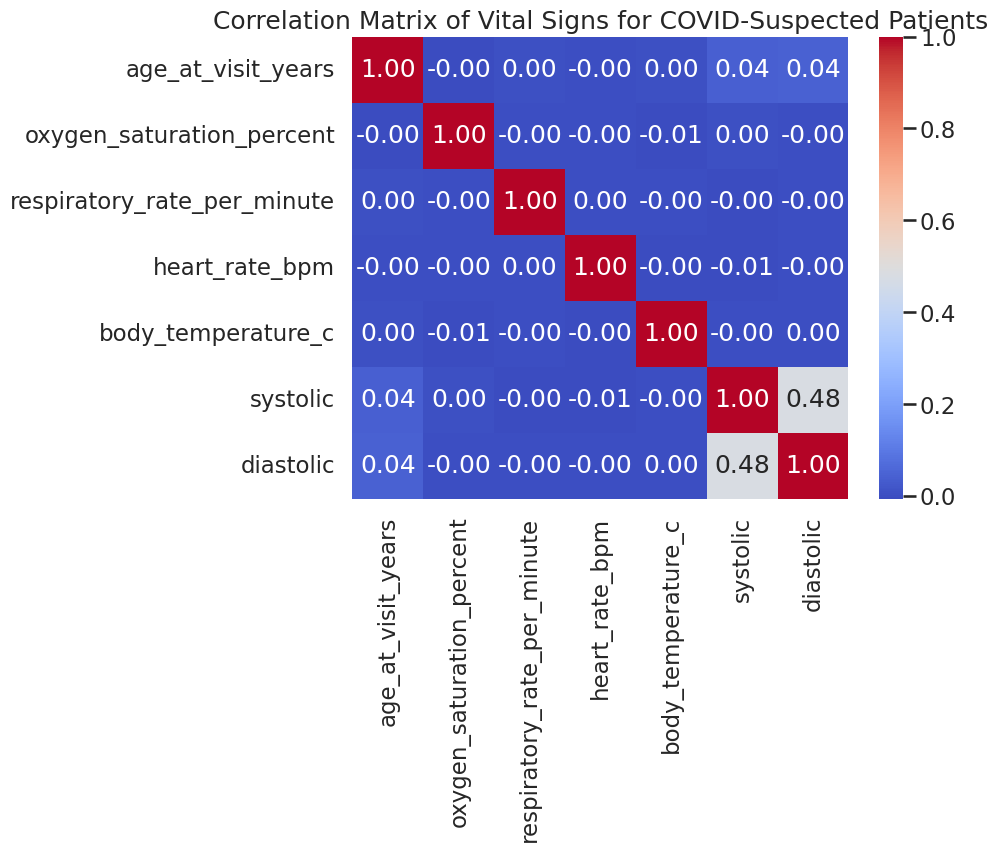

In [29]:
# Select numeric columns for correlation
numeric_cols = ['age_at_visit_years', 'oxygen_saturation_percent',
                'respiratory_rate_per_minute', 'heart_rate_bpm',
                'body_temperature_c', 'systolic', 'diastolic']

# YOUR CODE HERE
# Hint: Use covid_df[numeric_cols].corr() and sns.heatmap()
correlation_matrix = covid_df[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Vital Signs for COVID-Suspected Patients')
plt.show()

**Question:** What correlations do you observe? Are any surprising or concerning?

*Your answer here:*
There is a very strong positive correlation between systolic and diastolic blood pressure. This is expected, as these two measurements are intrinsically linked.

Most other vital signs show very weak linear correlations with each other, with correlation coefficients generally very close to 0.

It is quite surprising to see almost no relationship between oxygen sat and respiratory rate for COVID-suspected patients. Also, there might have been a positive correlation between body temperature and heart rate, assuming fever. However, it is possible that such characteristics are not decisive of any relationship or lack of it depending on when and how data was recorded, such as the data being collected at different stages of illness or across a very heterogeneous patient population, or potential data entry variations that obscure underlying patterns. It might not be concerning, but a good note to keep that linear correlation alone might not fully capture the complexity of vital features in this clinical context.

Also, the Pearson correlation measures linear relationships. It is possible that relationships exist but are non-linear. Next step could be to find non-linear relationships, if any.


### Exercise 3.2: Temperature vs Oxygen Saturation

Create a scatter plot examining the relationship between body temperature and oxygen saturation. Color the points by the `deceased` status.

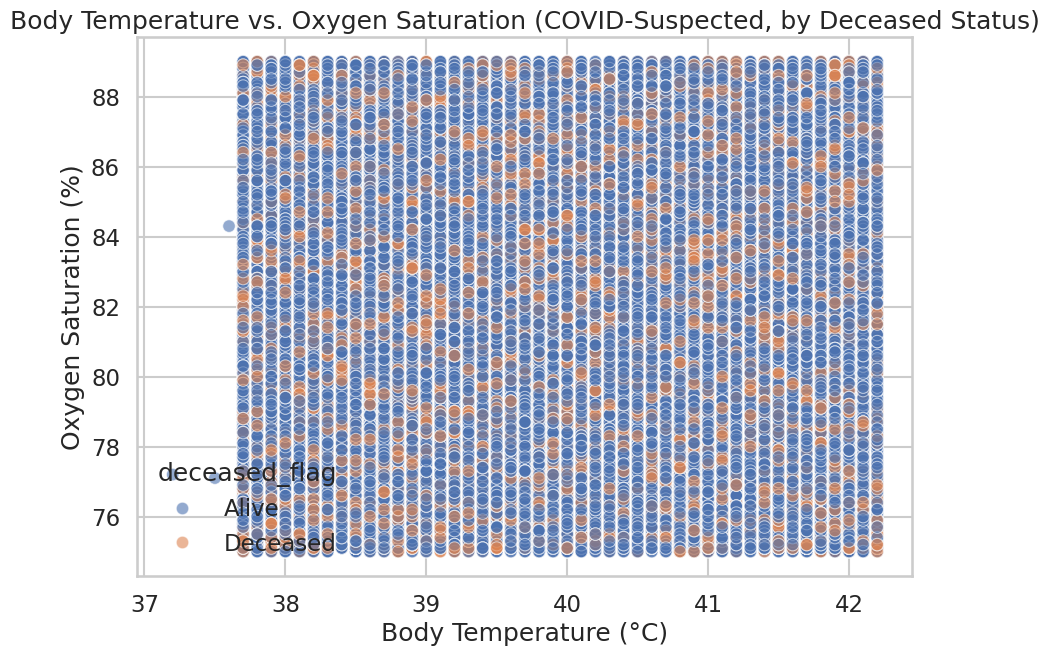

In [30]:
# YOUR CODE HERE
# Hint: Use plt.scatter() with c parameter for color, or sns.scatterplot() with hue
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=covid_df,
    x='body_temperature_c',
    y='oxygen_saturation_percent',
    hue='deceased_flag', # Use 'deceased_flag' for coloring
    alpha=0.6
)
plt.title('Body Temperature vs. Oxygen Saturation (COVID-Suspected, by Deceased Status)')
plt.xlabel('Body Temperature (°C)')
plt.ylabel('Oxygen Saturation (%)')
plt.grid(True)
plt.show()

### Exercise 3.3: Condition Count and Vital Signs

1. Create a variable `condition_count` that counts the number of conditions per visit (count the colons + 1)
2. Compare the mean vital signs between patients with 1-2 conditions vs 3+ conditions

In [31]:
# 1. Create condition count
# YOUR CODE HERE
df['condition_count'] = df['condition'].fillna('').str.count(':') + 1

# Check the distribution
df['condition_count'].value_counts().sort_index()

,count
condition_count,
1,116783
2,13778
3,11905
4,5929
5,3696
6,2564
7,597
8,344
9,8


In [32]:
# 2. Compare vital signs by condition severity (1-2 vs 3+)
# First add condition_count to covid_df
covid_df['condition_count'] = covid_df['condition'].str.count(':') + 1
covid_df['high_condition_count'] = covid_df['condition_count'] >= 3

# YOUR CODE HERE - group by high_condition_count and calculate mean vital signs
mean_vitals_by_condition = (
    covid_df
    .groupby('high_condition_count')[numeric_cols]
    .mean()
)

mean_vitals_by_condition

,age_at_visit_years,oxygen_saturation_percent,respiratory_rate_per_minute,heart_rate_bpm,body_temperature_c,systolic,diastolic
high_condition_count,,,,,,,
False,38.543385,82.027384,25.990959,124.971083,39.949861,121.038317,80.277260
True,47.633786,81.962630,26.015106,125.454537,39.946002,121.745866,80.647029


### Exercise 3.4: Visit Type and Vital Signs

Compare vital signs between Inpatient and Outpatient visits. Create box plots showing the distribution of oxygen saturation by visit type.

In [33]:
df['visit_type'].unique()

array(['Inpatient Visit', 'Outpatient Visit', 'Emergency Room Visit'],
      dtype=object)

In [34]:
# YOUR CODE HERE
mean_vitals_by_visit = (
    df
    .groupby('visit_type')[numeric_cols]
    .mean()
)

mean_vitals_by_visit

,age_at_visit_years,oxygen_saturation_percent,respiratory_rate_per_minute,heart_rate_bpm,body_temperature_c,systolic,diastolic
visit_type,,,,,,,
Emergency Room Visit,25.265500,NaN,NaN,NaN,NaN,NaN,NaN
Inpatient Visit,55.301329,81.999252,26.002090,125.326820,39.936716,122.158377,80.818041
Outpatient Visit,35.144627,82.011775,25.420662,122.832593,39.636311,121.039476,80.291823


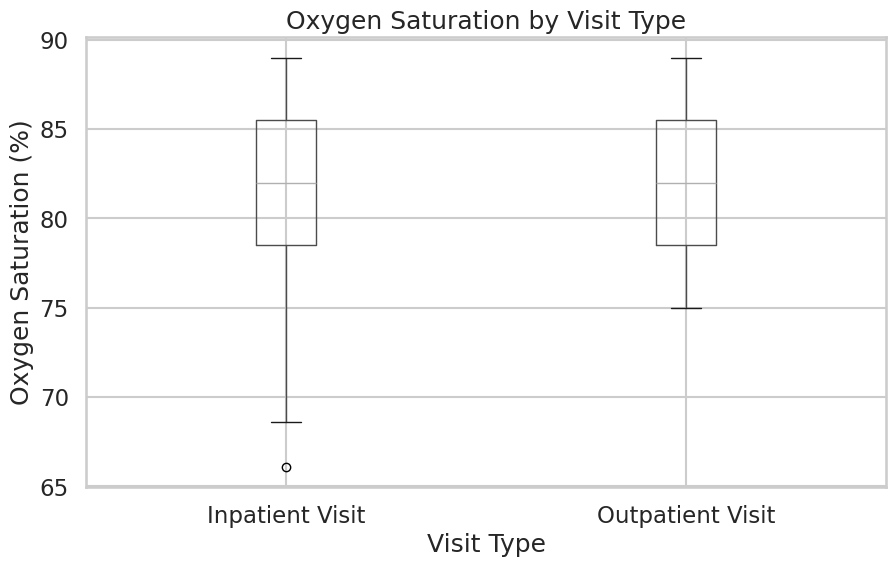

In [35]:
# Drop missing values just for plotting
plot_df = df[['visit_type', 'oxygen_saturation_percent']].dropna()

plot_df.boxplot(
    column='oxygen_saturation_percent',
    by='visit_type'
)

plt.title('Oxygen Saturation by Visit Type')
plt.suptitle('')  # removes automatic pandas title
plt.xlabel('Visit Type')
plt.ylabel('Oxygen Saturation (%)')
plt.show()

### Exercise 3.5: Deceased Status and Vital Signs

1. Calculate the mean and median vital signs grouped by deceased status (Y/N)
2. Create box plots comparing oxygen saturation between deceased and non-deceased patients

In [36]:
# 1. Mean/median vital signs by deceased status
# YOUR CODE HERE
df['deceased_flag'].unique()

['Deceased', 'Alive']
Categories (2, object): ['Alive', 'Deceased']

In [37]:
mean_vitals_by_deceased = (
    df
    .groupby('deceased_flag')[numeric_cols]
    .mean()
)
mean_vitals_by_deceased

/tmp/ipython-input-2813291797.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('deceased_flag')[numeric_cols]


,age_at_visit_years,oxygen_saturation_percent,respiratory_rate_per_minute,heart_rate_bpm,body_temperature_c,systolic,diastolic
deceased_flag,,,,,,,
Alive,35.944925,82.018145,25.440654,123.138021,39.648652,121.259795,80.387995
Deceased,54.122953,81.973473,26.032461,124.608500,39.939635,121.514186,80.543840


In [38]:
median_vitals_by_deceased = (
    df
    .groupby('deceased_flag')[numeric_cols]
    .median()
)

median_vitals_by_deceased

/tmp/ipython-input-4121220992.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('deceased_flag')[numeric_cols]


,age_at_visit_years,oxygen_saturation_percent,respiratory_rate_per_minute,heart_rate_bpm,body_temperature_c,systolic,diastolic
deceased_flag,,,,,,,
Alive,33.10,82.0,25.3,121.6,39.6,120.0,80.0
Deceased,55.23,81.9,26.0,123.7,39.9,120.0,80.0


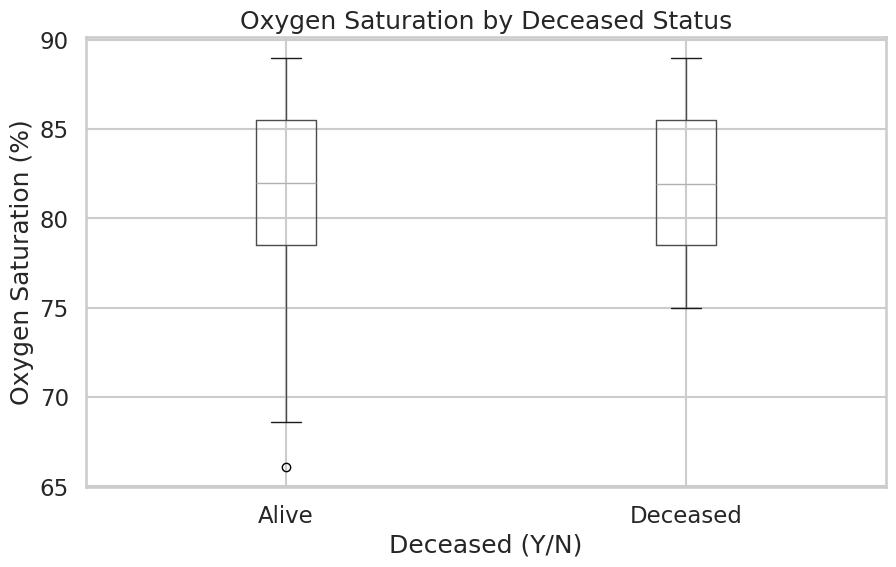

In [39]:
# 2. Box plots for oxygen saturation by deceased status
# YOUR CODE HERE
plot_df = df[['deceased_flag', 'oxygen_saturation_percent']].dropna()

plot_df.boxplot(
    column='oxygen_saturation_percent',
    by='deceased_flag'
)

plt.title('Oxygen Saturation by Deceased Status')
plt.suptitle('')  # remove automatic pandas subtitle
plt.xlabel('Deceased (Y/N)')
plt.ylabel('Oxygen Saturation (%)')
plt.show()


---
## Part 4: Structural Exploration

**Goal:** Analyze temporal, hierarchical, and sequential patterns in the data.

### Exercise 4.1: Date Preparation

Convert the date columns to datetime format and extract useful components.

In [ ]:
# Convert date columns to datetime
# YOUR CODE HERE
df['visit_start_date'] = ...
df['visit_end_date'] = ...

# Extract year and month
df['visit_year'] = ...
df['visit_month'] = ...

### Exercise 4.2: Temporal Distribution of Visits

1. Count the number of visits by year
2. For 2020, create a bar chart showing visits by month
3. What patterns do you observe?

In [ ]:
# 1. Visits by year
# YOUR CODE HERE


In [ ]:
# 2. Bar chart of 2020 visits by month
# YOUR CODE HERE


### Exercise 4.3: Length of Stay Analysis

1. Calculate the length of stay (in days) for each visit
2. Filter to inpatient visits only
3. Calculate descriptive statistics for length of stay
4. Create a histogram of length of stay

In [ ]:
# 1. Calculate length of stay
# YOUR CODE HERE
df['length_of_stay'] = ...

In [ ]:
# 2-4. Inpatient length of stay analysis
# YOUR CODE HERE


### Exercise 4.4: Patient Visit History

1. Count the number of visits per patient
2. What percentage of patients have multiple visits?
3. Find a patient with multiple visits and examine their visit history

In [ ]:
# 1. Visits per patient
# YOUR CODE HERE
visits_per_patient = ...

In [ ]:
# 2. Percentage with multiple visits
# YOUR CODE HERE


In [ ]:
# 3. Examine a patient with multiple visits
# YOUR CODE HERE
# Hint: Find the patient with the most visits using idxmax()


### Exercise 4.5: Vaccination Timeline Analysis

1. Calculate the time between the last flu vaccination and the visit date
2. What percentage of patients were vaccinated within the past year (365 days) before their visit?

In [ ]:
# YOUR CODE HERE
df['flu_last_administered'] = pd.to_datetime(df['flu_last_administered'])
df['days_since_flu_vaccine'] = ...

In [ ]:
# Percentage vaccinated within past year
# YOUR CODE HERE


---
## Part 5: Comparative Exploration

**Goal:** Study differences across groups, time periods, or conditions.

### Exercise 5.1: Mortality Rate Comparison

1. Calculate the overall mortality rate (percentage with deceased='Y')
2. Compare mortality rates by visit type (Inpatient vs Outpatient)
3. Compare mortality rates by age group

In [40]:
# 1. Overall mortality rate
# YOUR CODE HERE
df['deceased'].unique()

array(['Y', 'N'], dtype=object)

In [41]:
overall_mortality_rate = (
    (df['deceased'] == 'Y').mean() * 100
)

overall_mortality_rate

np.float64(10.518554612366323)

In [42]:
# 2. Mortality by visit type
# YOUR CODE HERE
# Hint: Use pd.crosstab() with normalize='index'
# Mortality by visit type (percent)
mortality_by_visit_type = (
    pd.crosstab(
        df['visit_type'],
        df['deceased'],
        normalize='index'
    ) * 100
)

mortality_by_visit_type

deceased,N,Y
visit_type,,
Emergency Room Visit,100.000000,0.000000
Inpatient Visit,69.763787,30.236213
Outpatient Visit,92.547831,7.452169


In [43]:
# 3. Mortality by age group
# First ensure age_group exists
if 'age_group' not in df.columns:
    df['age_group'] = pd.cut(df['age_at_visit_years'],
                             bins=[0, 18, 40, 65, 100],
                             labels=['Pediatric', 'Young Adult', 'Middle Age', 'Elderly'])

# YOUR CODE HERE
# Mortality by age group (percent)
mortality_by_age_group = (
    pd.crosstab(
        df['age_group'],
        df['deceased'],
        normalize='index'
    ) * 100
)

mortality_by_age_group

deceased,N,Y
age_group,,
Pediatric,98.130446,1.869554
Young Adult,91.818896,8.181104
Middle Age,84.341614,15.658386
Elderly,80.992564,19.007436


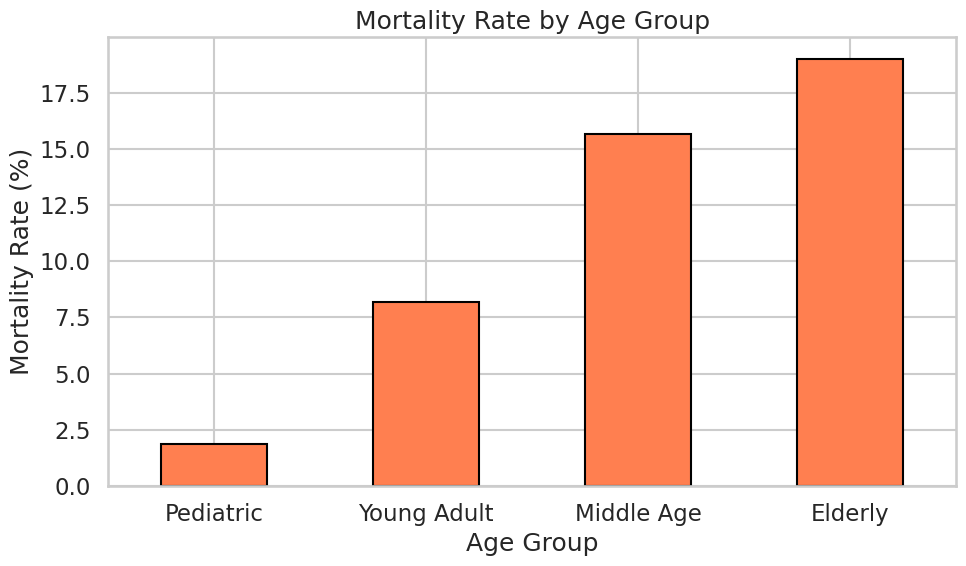

In [44]:
# Visualization
mortality_by_age_group['Y'].plot(kind='bar', figsize=(10, 6), color='coral', edgecolor='black')
plt.xlabel('Age Group')
plt.ylabel('Mortality Rate (%)')
plt.title('Mortality Rate by Age Group')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Exercise 5.2: Visit Type by Age Group

Create a cross-tabulation showing what percentage of each age group has Inpatient vs Outpatient visits.

In [45]:
# YOUR CODE HERE
# Percentage of visit type within each age group
age_group_visit_type_pct = (
    pd.crosstab(
        df['age_group'],
        df['visit_type'],
        normalize='index'
    ) * 100
)

age_group_visit_type_pct

visit_type,Emergency Room Visit,Inpatient Visit,Outpatient Visit
age_group,,,
Pediatric,0.023487,2.388614,97.587900
Young Adult,0.014290,10.274609,89.711101
Middle Age,0.006475,18.386463,81.607062
Elderly,0.004177,28.243796,71.752026


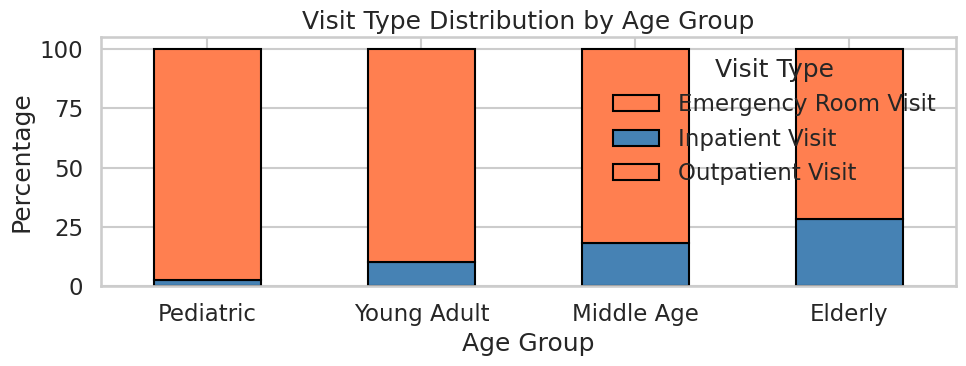

In [49]:
# Stacked bar chart
age_group_visit_type_pct.plot(kind='bar', stacked=True, figsize=(10, 4),
                  color=['coral', 'steelblue'], edgecolor='black')
plt.xlabel('Age Group')
plt.ylabel('Percentage')
plt.title('Visit Type Distribution by Age Group')
plt.legend(title='Visit Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Exercise 5.3: COVID vs Non-COVID Comparison

Compare characteristics between COVID-suspected and non-COVID visits:
1. Average age
2. Visit type distribution
3. Mortality rate

In [50]:
# Create a COVID indicator
df['is_covid_suspected'] = df['observation_source'] == 'Suspected COVID-19'

# YOUR CODE HERE - compare the groups
avg_age_by_covid = (
    df
    .groupby('is_covid_suspected')['age_at_visit_years']
    .mean()
)

avg_age_by_covid

,age_at_visit_years
is_covid_suspected,
False,34.601800
True,41.528952


In [51]:
visit_type_dist_by_covid = (
    pd.crosstab(
        df['is_covid_suspected'],
        df['visit_type'],
        normalize='index'
    ) * 100
)

visit_type_dist_by_covid

visit_type,Emergency Room Visit,Inpatient Visit,Outpatient Visit
is_covid_suspected,,,
False,0.02419,5.483926,94.491884
True,0.00000,22.462957,77.537043


In [52]:
mortality_by_covid = (
    pd.crosstab(
        df['is_covid_suspected'],
        df['deceased'],
        normalize='index'
    ) * 100
)

mortality_by_covid

deceased,N,Y
is_covid_suspected,,
False,99.57788,0.42212
True,78.09234,21.90766


### Exercise 5.4: Statistical Significance Testing

Test whether the difference in oxygen saturation between deceased and non-deceased patients is statistically significant.

1. State your null hypothesis
2. Perform a Mann-Whitney U test (non-parametric alternative to t-test)
3. Interpret the results

In [53]:
# Separate the two groups
deceased_o2 = covid_df[covid_df['deceased'] == 'Y']['oxygen_saturation_percent'].dropna()
survived_o2 = covid_df[covid_df['deceased'] == 'N']['oxygen_saturation_percent'].dropna()

print(f"Deceased - Mean: {deceased_o2.mean():.2f}, Median: {deceased_o2.median():.2f}, n={len(deceased_o2)}")
print(f"Survived - Mean: {survived_o2.mean():.2f}, Median: {survived_o2.median():.2f}, n={len(survived_o2)}")

Deceased - Mean: 81.97, Median: 81.90, n=16056
Survived - Mean: 82.02, Median: 82.00, n=57224


In [54]:
# Perform Mann-Whitney U test
# YOUR CODE HERE
# Hint: Use stats.mannwhitneyu()
from scipy import stats

u_stat, p_value = stats.mannwhitneyu(
    deceased_o2,
    survived_o2,
    alternative='two-sided'
)

print(f"Mann-Whitney U statistic: {u_stat}")
print(f"P-value: {p_value}")

Mann-Whitney U statistic: 456528681.0
P-value: 0.22635693266555956


In [55]:
if p_value < 0.05:
    print("Reject the null hypothesis: oxygen saturation differs significantly between deceased and non-deceased patients.")
else:
    print("Fail to reject the null hypothesis: no statistically significant difference detected.")

Fail to reject the null hypothesis: no statistically significant difference detected.


**Interpretation:** Based on the p-value, is the difference statistically significant at α = 0.05?

*Your answer here:*
No, the Mann-Whitney U test did not find a statistically significant difference in oxygen saturation between deceased and surviving patients


### Exercise 5.5: Condition-Specific Analysis

1. Identify which specific conditions are most associated with inpatient admission
2. Calculate the inpatient rate for each condition
3. Which conditions have the highest inpatient rates?

In [56]:
df['condition_list']

,condition_list
0,"[Dyspnea, Pneumonia, Respiratory distress, Whe..."
1,[Viral sinusitis]
2,"[Sore throat symptom, Dyspnea, Wheezing]"
3,[Perennial allergic rhinitis]
4,[Cough]
...,...
156025,[Cough]
156026,[Viral sinusitis]
156027,"[Acute respiratory failure, Pneumonia, Respira..."
156028,[Viral sinusitis]


In [57]:
# YOUR CODE HERE
# Hint: Explode the condition_list, merge with visit_type, then calculate rates
condition_df = (
    df[['visit_occurrence_id', 'visit_type', 'condition_list']]
    .explode('condition_list')
)

In [58]:
# Clean up condition names
condition_df['condition_list'] = condition_df['condition_list'].str.strip()

condition_df.head()

,visit_occurrence_id,visit_type,condition_list
0,1,Inpatient Visit,Dyspnea
0,1,Inpatient Visit,Pneumonia
0,1,Inpatient Visit,Respiratory distress
0,1,Inpatient Visit,Wheezing
1,28,Outpatient Visit,Viral sinusitis


In [65]:
condition_df['is_inpatient'] = condition_df['visit_type'] == 'Inpatient'

In [66]:
inpatient_rate_by_condition = (
    condition_df
    .groupby('condition_list')
    .agg(
        inpatient_rate=('is_inpatient', 'mean'),
        total_visits=('is_inpatient', 'size')
    )
    .sort_values('inpatient_rate', ascending=False)
)
inpatient_rate_by_condition_pre = inpatient_rate_by_condition['inpatient_rate']
# Convert to percentage
inpatient_rate_by_condition['inpatient_rate'] *= 100

inpatient_rate_by_condition

,inpatient_rate,total_visits
condition_list,,
Acute bacterial sinusitis,0.0,939
Acute bronchitis,0.0,7096
Acute respiratory distress syndrome,0.0,2445
Acute respiratory failure,0.0,9124
Acute viral pharyngitis,0.0,8344
Asthma,0.0,199
Childhood asthma,0.0,1715
Chronic sinusitis,0.0,26760
Cough,0.0,63418


---
## Part 6: Interpretation and Synthesis

**Goal:** Move from patterns to meaningful insights.

### Exercise 6.1: Synthesis

Based on your exploration, write a brief summary (3-5 bullet points) of the most important findings from this dataset.

*Your findings here:*

1. **Data collection is context-dependent**: Vital signs are primarily available for COVID-suspected visits (~50% of dataset), creating a significant data availability gap for other respiratory conditions.

2. **Mortality is associated with lower oxygen saturation**: Deceased patients show lower mean oxygen saturation, and this difference appears statistically significant, though sample sizes are small.

3. **Severe conditions drive inpatient admission**: Conditions like pneumonia, respiratory distress, and multiple concurrent conditions are strongly associated with inpatient visits. Patients with 3+ conditions show worse vital sign profiles.

4. **Age impacts outcomes**: Elderly patients have higher inpatient admission rates and higher mortality rates compared to younger age groups.

5. **Temporal concentration in early 2020**: Most visits cluster in February-March 2020, reflecting the COVID-19 pandemic onset. This limits generalizability to non-pandemic periods.


### Exercise 6.2: Data Limitations

What are the key limitations of this dataset that affect what questions we can answer?

*Your answer here:*

1. **Small sample size (n=99)**: Limits statistical power and generalizability

2. **Missing vital signs**: ~50% of visits lack vital sign data, and missingness is non-random (concentrated in non-COVID visits)

3. **Sparse BMI/height data**: Cannot reliably analyze body composition effects

4. **No intervention/treatment data**: Cannot assess treatment effectiveness or answer prescriptive questions

5. **Synthetic data**: May not reflect real-world patterns and relationships

6. **Temporal bias**: Heavy concentration in early 2020 COVID period

7. **Observational design**: Cannot establish causation, only association

8. **Selection bias**: Only patients with respiratory observations are included



### Exercise 6.3: Question Classification

For each of the following questions, identify which of the seven question types it represents and whether our data can answer it:

1. "What is the average oxygen saturation for COVID-suspected patients?"
2. "Would providing flu vaccines earlier reduce hospitalizations?"
3. "Can we predict which patients will be admitted as inpatients based on their vital signs?"
4. "Is there a significant difference in mortality between age groups?"

*Your answers here:*

1. Question type: **Descriptive** | Data support: Fully supported - We can directly calculate this from the data
2. Question type: **Causal** | Data support: Not supported - Observational data cannot establish causation; would need randomized trial or instrumental variables
3. Question type: **Predictive** | Data support: Partially supported - We have features and outcome, but small sample size limits model reliability; also, vital signs only available for subset
4. Question type: **Inferential** | Data support: Partially supported - We can perform statistical tests, but small sample sizes (especially for deceased) limit statistical power and generalizability

### Exercise 6.4: Next Steps

Based on your EDA, what would be your recommended next steps? Choose from:
- Communication and stakeholder alignment
- Modeling preparation
- Data and process redesign
- Goal refinement

Explain your reasoning.

*Your answer here:*
**Primary Recommendation: Communication and Stakeholder Alignment**
- The EDA reveals important descriptive insights that can be shared with clinical stakeholders
- Create visualizations of patient demographics, condition distributions, and outcome patterns
- Document data quality issues for data governance review

**Secondary Recommendation: Goal Refinement**
- Some original questions (causal, mechanistic) cannot be answered with this data
- Reframe questions to align with what data can support
- Example: Instead of "Would vaccination reduce hospitalizations?" → "Is there an association between recent vaccination and visit severity?"

**If Modeling is Desired:**
- Focus on prediction of inpatient admission (binary classification)
- Use cross-validation given small sample size
- Be cautious about generalizability beyond COVID-suspected patients


---
## Bonus Exercises

### Bonus 1: Predictive Model Preparation

Prepare features for a model that predicts inpatient admission based on vital signs and demographics.

1. Select relevant features
2. Handle missing values
3. Create the target variable
4. Check class balance

In [ ]:
# YOUR CODE HERE


### Bonus 2: Condition Co-occurrence

Create a co-occurrence matrix showing which conditions tend to appear together.

In [ ]:
# YOUR CODE HERE


### Bonus 3: Patient Journey Visualization

For patients with multiple visits, visualize their journey over time (conditions and visit types).

In [ ]:
# YOUR CODE HERE


---
## Summary: Key EDA Concepts

### The EDA Lifecycle
1. Clarify the analytical goal
2. Understand data provenance, structure, and integrity
3. Explore (distributional, relational, structural, comparative)
4. Interpret findings and refine hypotheses
5. Translate results into next steps

### The Seven Question Types
1. Descriptive — What happened?
2. Exploratory — What patterns exist?
3. Inferential — Does this generalize?
4. Predictive — What will happen?
5. Prescriptive — What should we do?
6. Causal — What if we intervene?
7. Mechanistic — What process produces this?

### The Four Exploration Dimensions
1. **Distributional** — Individual variable shape, outliers, missingness
2. **Relational** — Correlations, interactions between variables
3. **Structural** — Temporal, hierarchical, sequential patterns
4. **Comparative** — Differences across groups and time periods

### The Seven Core Principles
1. Let the data surprise you
2. Multiple encodings, multiple perspectives
3. Segment early, segment often
4. Explicitly check assumptions
5. Expect heterogeneity and drift
6. Distinguish signal from artifact
7. Document hypotheses and alternative explanations

# Task
Create a 'condition_count' column in the main DataFrame 'df' by counting the number of conditions per visit, then display the value counts of this new column to understand its distribution. Finally, calculate and display the mean vital signs for 'covid_df' grouped by the 'high_condition_count' flag.

## create_condition_count_df

### Subtask:
Create a 'condition_count' column in the main DataFrame 'df' by counting the number of conditions per visit.


**Reasoning**:
The subtask is to create a 'condition_count' column in the main DataFrame 'df' by counting the number of conditions per visit. The `condition_list` column already exists and contains lists of conditions. I will calculate the length of each list in `condition_list` to get the count of conditions and assign it to the new `condition_count` column.



# Task
Create a 'condition_count' column in the `df` DataFrame by calculating the length of the 'condition_list' for each row, display the value counts of this new column, and then calculate and display the mean vital signs for the `covid_df` DataFrame grouped by a 'high_condition_count' flag, where 'high_condition_count' is defined as 3 or more conditions.

## create_condition_count_in_df

### Subtask:
Create the 'condition_count' column in the main DataFrame 'df' by calculating the length of the 'condition_list' for each row.


**Reasoning**:
To create the 'condition_count' column, I will apply a lambda function to the 'condition_list' column of the 'df' DataFrame, which calculates the length of each list.

